In [1]:
# To turn off Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importing the diabetes dataset
d1 = pd.read_csv('diabetes.csv')
d2 = pd.read_csv('indian_diabetes_synthetic_100k.csv')
df = pd.concat([d1, d2], ignore_index=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Exploratory Data Analysis
df.info()
df.shape
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100768 entries, 0 to 100767
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Pregnancies               100768 non-null  int64  
 1   Glucose                   100768 non-null  int64  
 2   BloodPressure             100768 non-null  int64  
 3   SkinThickness             100768 non-null  int64  
 4   Insulin                   100768 non-null  int64  
 5   BMI                       100768 non-null  float64
 6   DiabetesPedigreeFunction  100768 non-null  float64
 7   Age                       100768 non-null  int64  
 8   Outcome                   100768 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 6.9 MB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000
mean,2.454718,113.176276,77.405228,27.523073,67.222541,27.311425,0.499253,35.487982,0.303291
std,2.342538,33.310100,12.043445,9.925014,64.107922,5.545445,0.348528,9.456015,0.459682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,88.000000,69.000000,21.000000,24.000000,23.500000,0.262000,29.000000,0.000000
50%,2.000000,107.000000,77.000000,27.000000,49.000000,27.300000,0.406000,34.000000,0.000000
75%,4.000000,137.000000,86.000000,34.000000,90.000000,31.000000,0.630000,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Data Cleaning
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
# Check the features with 0 value
zero_counts = df.eq(0).sum()
print(zero_counts)

Pregnancies                 20452
Glucose                         5
BloodPressure                  35
SkinThickness                 227
Insulin                       374
BMI                            11
DiabetesPedigreeFunction        0
Age                             0
Outcome                     70206
dtype: int64


In [7]:
# Replace Zero values in important features with median value
df['Glucose'] = df['Glucose'].replace(0, np.median(df['Glucose']))

df['BloodPressure'] = df['BloodPressure'].replace(0, np.median(df['BloodPressure']))

df['SkinThickness'] = df['SkinThickness'].replace(0, np.median(df['SkinThickness']))

df['Insulin'] = df['Insulin'].replace(0, np.median(df['Insulin']))

df['BMI'] = df['BMI'].replace(0, np.median(df['BMI']))

In [8]:
zero_counts = df.eq(0).sum()

print(zero_counts)

Pregnancies                 20452
Glucose                         0
BloodPressure                   0
SkinThickness                   0
Insulin                         0
BMI                             0
DiabetesPedigreeFunction        0
Age                             0
Outcome                     70206
dtype: int64


In [9]:
# Understanding the correlation between features and Outcome
# Get list of feature columns (excluding target)

feature_columns = [col for col in df.columns if col != 'Outcome']



for feature in feature_columns:

    correlation = df[feature].corr(df["Outcome"])

    print('Correlation for ', feature, ' = ', correlation)

Correlation for  Pregnancies  =  0.07053767795660078
Correlation for  Glucose  =  0.7997096430702022
Correlation for  BloodPressure  =  0.045280010078834226
Correlation for  SkinThickness  =  0.06293887273636804
Correlation for  Insulin  =  0.5352295601382486
Correlation for  BMI  =  0.38222791566047304
Correlation for  DiabetesPedigreeFunction  =  0.301389769404278
Correlation for  Age  =  0.1403193799018433


<Axes: >

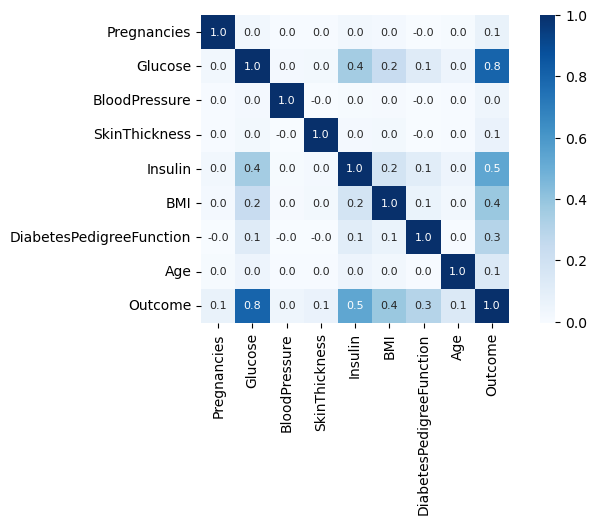

In [10]:
corr = df.corr()

# constructing a heatmap to nderstand the correlation

plt.figure(figsize=(8,4))

sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, 

            annot_kws={'size':8}, cmap='Blues')

In [20]:
# KNN Model
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Create features and target

X = df.drop('Outcome', axis=1) 

y = df['Outcome']

# Split the data into training and testing sets

X_train = d2.drop('Outcome', axis=1)

y_train = d2['Outcome']

X_test = d1.drop('Outcome', axis=1)

y_test = d1['Outcome']



# Feature scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('knn', KNeighborsClassifier())

])



param_grid = {

    'knn__n_neighbors': [3, 5, 7, 9, 11, 13],

    'knn__weights': ['uniform', 'distance'],

    'knn__p': [1, 2]  # 1: Manhattan distance, 2: Euclidean distance

}

In [21]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

# Get best parameters and model accuracy

best_params = grid_search.best_params_

best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

Best Parameters: {'knn__n_neighbors': 13, 'knn__p': 2, 'knn__weights': 'distance'}


In [22]:
from sklearn.metrics import accuracy_score



y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Set Accuracy:", test_accuracy)

Test Set Accuracy: 0.7265625
